# Rad-Scribe Pro — Notebook 2: Data Preprocessing
**Symbiosis Institute of Technology | Dept. of AI & ML**

Team: Tejas Kale · Hardik Gulati · Swaraj Deogirkar | Mentor: Dr. Zulfikar Ali Ansari

### What this notebook does
1. Loads IU X-Ray dataset
2. Cleans report text (removes XXXX, normalizes)
3. Labels each report using IMPRESSION-based classifier
4. Analyzes token lengths — decides MAX_SEQ_LEN
5. Balances dataset — fixes class imbalance
6. Stratified train / val / test split
7. Saves parquet files used by all model notebooks

> Output: `train.parquet`, `val.parquet`, `test.parquet`, `meta.json`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q datasets pandas pyarrow transformers scikit-learn
print('done')

done


In [ ]:
import os, re, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from datasets import load_dataset
from transformers import GPT2Tokenizer
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

DATA_DIR = '/content/drive/MyDrive/Radscribe/radscribe_data'
os.makedirs(DATA_DIR, exist_ok=True)

print('Loading IU X-Ray dataset...')
raw = load_dataset('MLforHealthcare/Indiana_University_Chest_X-ray_Collection')
print(f'Train: {len(raw["train"]):,}  Test: {len(raw["test"]):,}')

Loading IU X-Ray dataset...


README.md:   0%|          | 0.00/463 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/407M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/411M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/410M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/135M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6687 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/743 [00:00<?, ? examples/s]

Train: 6,687  Test: 743


---
## Step 1 — Text Cleaning

In [ ]:
def clean_report(text):
    """
    Clean a single radiology report:
    - Remove XXXX anonymisation tokens
    - Collapse multiple spaces/newlines
    - Remove non-ASCII characters
    - Strip leading/trailing whitespace
    Returns None if report is too short to be useful
    """
    text = str(text or '')
    text = re.sub(r'xxxx+', '', text, flags=re.IGNORECASE)  # remove XXXX tokens
    text = re.sub(r'[^\x00-\x7F]', '', text)              # remove non-ASCII
    text = re.sub(r'\s+', ' ', text)                        # collapse whitespace
    text = re.sub(r'\.\s*\.', '.', text)                  # remove double periods
    text = text.strip()
    return text if len(text) > 15 else None                  # drop very short reports

# test on sample
sample_report = raw['train'][10]['report']
print('Original:')
print(sample_report[:300])
print()
print('Cleaned:')
print(clean_report(sample_report)[:300])

Original:
FINDINGS: Mild cardiomegaly. Hypoinflation of the lungs. Right basilar XXXX opacity may represent atelectasis. Lungs are otherwise clear without focal consolidation, pleural effusion, or pneumothorax. Sclerosis of the humeral XXXX bilateral, XXXX from prior AVN. Sclerotic vertebral body endplates wi

Cleaned:
FINDINGS: Mild cardiomegaly. Hypoinflation of the lungs. Right basilar opacity may represent atelectasis. Lungs are otherwise clear without focal consolidation, pleural effusion, or pneumothorax. Sclerosis of the humeral bilateral, from prior AVN. Sclerotic vertebral body endplates with central depr


---
## Step 2 — IMPRESSION-Based Classifier

In [ ]:
def get_impression(report):
    """Extract the IMPRESSION section from a report if present.
    The IMPRESSION is the radiologist's final conclusion — more reliable for classification.
    Falls back to full report if no IMPRESSION section found.
    """
    t = str(report).upper()
    if 'IMPRESSION:' in t:
        idx = t.index('IMPRESSION:')
        return str(report)[idx+11:].strip()
    return str(report)

def classify(r):
    """
    Classify a report as Normal (0), Abnormal (1), or Unclear (2).
    Uses IMPRESSION section first for more reliable classification.
    Counts keyword hits on both sides — side with more hits wins.
    Tie goes to Normal (conservative — avoids over-labelling pathology).
    """
    text = get_impression(r).lower()

    ABNORMAL = [
        'cardiomegaly','pneumonia','effusion','pneumothorax',
        'consolidation','atelectasis','opacity','infiltrate',
        'edema','fracture','nodule','mass','fibrosis',
        'hyperinflat','pleural','enlarged','tortuous',
        'degenerative','scoliosis','granuloma','calcif'
    ]
    NORMAL = [
        'no acute','normal','unremarkable','clear',
        'no significant','no evidence','negative',
        'within normal','no pneumothorax','no effusion',
        'no consolidation','no infiltrate'
    ]

    ab_hits = sum(1 for k in ABNORMAL if k in text)
    no_hits = sum(1 for k in NORMAL   if k in text)

    # fallback to full report if IMPRESSION had no hits
    if ab_hits == 0 and no_hits == 0:
        full    = str(r).lower()
        ab_hits = sum(1 for k in ABNORMAL if k in full)
        no_hits = sum(1 for k in NORMAL   if k in full)

    if ab_hits > no_hits:  return 1   # Abnormal
    if no_hits >= ab_hits: return 0   # Normal (tie -> Normal)
    return 2                          # Unclear

LABEL_MAP = {0: 'Normal', 1: 'Abnormal', 2: 'Unclear'}

# verify on known samples
print('Classifier verification:')
tests = [
    ('Lungs are clear. No pleural effusions. Heart normal.', 'Expect: Normal'),
    ('Mild cardiomegaly. Bilateral pleural effusions.', 'Expect: Abnormal'),
    ('No acute cardiopulmonary abnormality.', 'Expect: Normal'),
    ('IMPRESSION: Pneumonia right lower lobe.', 'Expect: Abnormal'),
]
for report, expected in tests:
    lbl = classify(report)
    print(f'  {LABEL_MAP[lbl]:10s} ({expected}) — {report[:60]}')

Classifier verification:
  Normal     (Expect: Normal) — Lungs are clear. No pleural effusions. Heart normal.
  Abnormal   (Expect: Abnormal) — Mild cardiomegaly. Bilateral pleural effusions.
  Normal     (Expect: Normal) — No acute cardiopulmonary abnormality.
  Abnormal   (Expect: Abnormal) — IMPRESSION: Pneumonia right lower lobe.


---
## Step 3 — Build Master DataFrame

In [ ]:
rows = []
skipped = 0

for split in raw.keys():
    for idx in range(len(raw[split])):
        item        = raw[split][idx]
        raw_report  = str(item.get('report', '') or '')
        clean       = clean_report(raw_report)

        if clean is None:
            skipped += 1
            continue

        rows.append({
            'hf_index'    : idx,
            'split'       : split,
            'report_raw'  : raw_report,
            'report'      : clean,
            'label'       : classify(clean),
        })

df = pd.DataFrame(rows)
df['label_name'] = df['label'].map(LABEL_MAP)

print(f'Total samples kept : {len(df):,}')
print(f'Skipped (too short): {skipped}')
print()
print('Label distribution:')
vc = df['label_name'].value_counts()
for label, count in vc.items():
    print(f'  {label:10s}: {count:,} ({count/len(df)*100:.1f}%)')
print()
df.head(3)

Total samples kept : 7,430
Skipped (too short): 0

Label distribution:
  Normal    : 5,556 (74.8%)
  Abnormal  : 1,874 (25.2%)



,hf_index,split,report_raw,report,label,label_name
0,0,train,FINDINGS: Lungs are clear. No pleural effusion...,FINDINGS: Lungs are clear. No pleural effusion...,1,Abnormal
1,1,train,FINDINGS: Hyperinflated lungs with mildly flat...,FINDINGS: Hyperinflated lungs with mildly flat...,1,Abnormal
2,2,train,FINDINGS: Borderline heart size. The lungs are...,FINDINGS: Borderline heart size. The lungs are...,1,Abnormal


---
## Step 4 — Token Length Analysis

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Computing token lengths...
Token length statistics:
count    7430.0
mean       68.3
std        29.5
min        13.0
25%        49.0
50%        63.0
75%        81.0
max       314.0
Name: token_len, dtype: float64
  max_len= 64 covers 53.3% of reports
  max_len= 96 covers 86.0% of reports
  max_len=128 covers 95.8% of reports
  max_len=160 covers 98.7% of reports
  max_len=200 covers 99.6% of reports


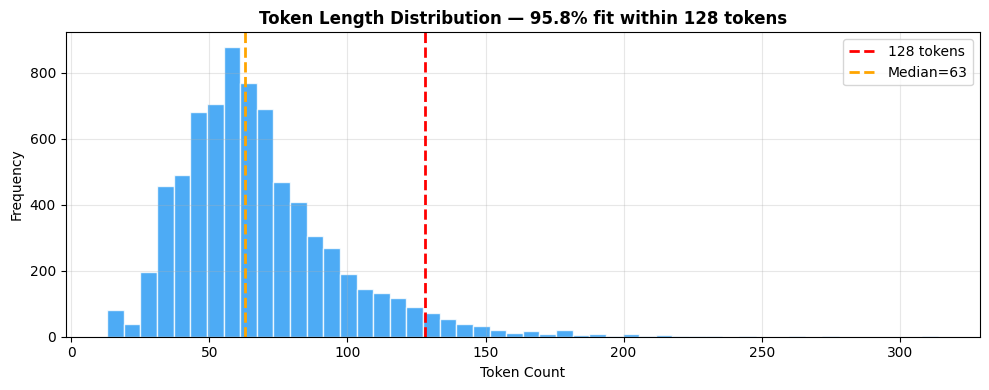


Decision: MAX_SEQ_LEN = 128 (covers 95.8% of reports)


In [ ]:
tokenizer = GPT2Tokenizer.from_pretrained('distilgpt2')
tokenizer.pad_token = tokenizer.eos_token

print('Computing token lengths...')
df['token_len'] = df['report'].apply(
    lambda x: len(tokenizer(x, truncation=False)['input_ids'])
)

print('Token length statistics:')
print(df['token_len'].describe().round(1))

# find optimal MAX_SEQ_LEN
for max_len in [64, 96, 128, 160, 200]:
    pct = (df['token_len'] <= max_len).mean() * 100
    print(f'  max_len={max_len:3d} covers {pct:.1f}% of reports')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['token_len'], bins=50, color='#2196F3', edgecolor='white', alpha=0.8)
ax.axvline(128, color='red',    linestyle='--', linewidth=2, label='128 tokens')
ax.axvline(df['token_len'].median(), color='orange', linestyle='--',
           linewidth=2, label=f'Median={df["token_len"].median():.0f}')
pct_128 = (df['token_len'] <= 128).mean() * 100
ax.set_xlabel('Token Count'); ax.set_ylabel('Frequency')
ax.set_title(f'Token Length Distribution — {pct_128:.1f}% fit within 128 tokens',
             fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f'\nDecision: MAX_SEQ_LEN = 128 (covers {pct_128:.1f}% of reports)')

---
## Step 5 — Train / Val / Test Split

In [ ]:
# use only the original train split for our train+val
# use the original test split as our test
df_trainval = df[df['split'] == 'train'].reset_index(drop=True)
df_test     = df[df['split'] == 'test' ].reset_index(drop=True)

print(f'Available for train+val : {len(df_trainval):,}')
print(f'Test (fixed)            : {len(df_test):,}')

# stratified split — preserves class ratio in train and val
df_train, df_val = train_test_split(
    df_trainval,
    test_size    = 0.15,
    random_state = 42,
    stratify     = df_trainval['label']
)
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)

print()
print(f'Train : {len(df_train):,}')
print(f'Val   : {len(df_val):,}')
print(f'Test  : {len(df_test):,}')

print()
print('Train class distribution:')
for l, c in df_train['label_name'].value_counts().items():
    print(f'  {l:10s}: {c:,} ({c/len(df_train)*100:.1f}%)')

Available for train+val : 6,687
Test (fixed)            : 743

Train : 5,683
Val   : 1,004
Test  : 743

Train class distribution:
  Normal    : 4,247 (74.7%)
  Abnormal  : 1,436 (25.3%)


---
## Step 6 — Balance Training Data

Before balancing:
  Normal  : 4,247
  Abnormal: 1,436
  Unclear : 0

After balancing:
  Normal    : 2,872 (66.7%)
  Abnormal  : 1,436 (33.3%)
  Total   : 4,308


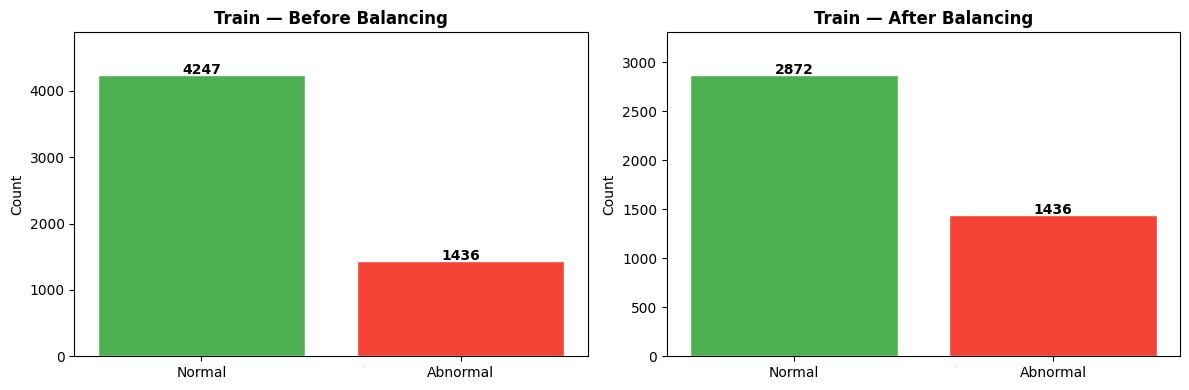

In [ ]:
# fix class imbalance by undersampling Normal in training set only
# val and test are kept as-is (real world distribution)
normal_df   = df_train[df_train['label'] == 0]
abnormal_df = df_train[df_train['label'] == 1]
unclear_df  = df_train[df_train['label'] == 2]

print(f'Before balancing:')
print(f'  Normal  : {len(normal_df):,}')
print(f'  Abnormal: {len(abnormal_df):,}')
print(f'  Unclear : {len(unclear_df):,}')

# undersample Normal to 2x Abnormal count — keeps some imbalance but reduces bias
target_normal = min(len(normal_df), len(abnormal_df) * 2)
normal_balanced = normal_df.sample(n=target_normal, random_state=42)

df_train_balanced = pd.concat([normal_balanced, abnormal_df, unclear_df])
df_train_balanced = df_train_balanced.sample(
    frac=1, random_state=42).reset_index(drop=True)

print()
print(f'After balancing:')
for l, c in df_train_balanced['label_name'].value_counts().items():
    print(f'  {l:10s}: {c:,} ({c/len(df_train_balanced)*100:.1f}%)')
print(f'  Total   : {len(df_train_balanced):,}')

# visualize before/after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
color_map = {'Normal':'#4CAF50','Abnormal':'#F44336','Unclear':'#FF9800'}

before_counts = df_train['label_name'].value_counts()
after_counts  = df_train_balanced['label_name'].value_counts()

for ax, counts, title in zip(axes,
        [before_counts, after_counts],
        ['Train — Before Balancing', 'Train — After Balancing']):
    colors = [color_map[l] for l in counts.index]
    ax.bar(counts.index, counts.values, color=colors, edgecolor='white')
    for i, v in enumerate(counts.values):
        ax.text(i, v+10, str(v), ha='center', fontweight='bold')
    ax.set_ylabel('Count'); ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, max(counts.values) * 1.15)

plt.tight_layout(); plt.show()

# use balanced train from now on
df_train = df_train_balanced

---
## Step 7 — Final Verification

In [ ]:
print('='*55)
print('FINAL DATASET SUMMARY')
print('='*55)
print(f'  Train : {len(df_train):,} samples')
print(f'  Val   : {len(df_val):,} samples')
print(f'  Test  : {len(df_test):,} samples')
print(f'  Total : {len(df_train)+len(df_val)+len(df_test):,} samples')
print()
print('Train label distribution:')
for l, c in df_train['label_name'].value_counts().items():
    print(f'  {l:10s}: {c:,} ({c/len(df_train)*100:.1f}%)')
print()
print('Val label distribution:')
for l, c in df_val['label_name'].value_counts().items():
    print(f'  {l:10s}: {c:,} ({c/len(df_val)*100:.1f}%)')
print()
print('Test label distribution:')
for l, c in df_test['label_name'].value_counts().items():
    print(f'  {l:10s}: {c:,} ({c/len(df_test)*100:.1f}%)')
print()
print('Columns saved:')
print(f'  {list(df_train.columns)}')
print('='*55)

FINAL DATASET SUMMARY
  Train : 4,308 samples
  Val   : 1,004 samples
  Test  : 743 samples
  Total : 6,055 samples

Train label distribution:
  Normal    : 2,872 (66.7%)
  Abnormal  : 1,436 (33.3%)

Val label distribution:
  Normal    : 750 (74.7%)
  Abnormal  : 254 (25.3%)

Test label distribution:
  Normal    : 559 (75.2%)
  Abnormal  : 184 (24.8%)

Columns saved:
  ['hf_index', 'split', 'report_raw', 'report', 'label', 'label_name', 'token_len']


---
## Step 8 — Save to Disk

In [ ]:
# columns to save
SAVE_COLS = ['hf_index','split','report_raw','report','label','label_name','token_len']

df_train[SAVE_COLS].to_parquet(f'{DATA_DIR}/train.parquet', index=False)
df_val  [SAVE_COLS].to_parquet(f'{DATA_DIR}/val.parquet',   index=False)
df_test [SAVE_COLS].to_parquet(f'{DATA_DIR}/test.parquet',  index=False)

meta = {
    'train_size'  : len(df_train),
    'val_size'    : len(df_val),
    'test_size'   : len(df_test),
    'max_seq_len' : 128,
    'label_map'   : {'0':'Normal','1':'Abnormal','2':'Unclear'},
    'tokenizer'   : 'distilgpt2',
    'dataset'     : 'MLforHealthcare/Indiana_University_Chest_X-ray_Collection',
    'balanced'    : True,
    'balance_strategy': 'Normal undersampled to 2x Abnormal count in train only'
}
with open(f'{DATA_DIR}/meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved:')
print(f'  {DATA_DIR}/train.parquet  — {len(df_train):,} rows')
print(f'  {DATA_DIR}/val.parquet    — {len(df_val):,} rows')
print(f'  {DATA_DIR}/test.parquet   — {len(df_test):,} rows')
print(f'  {DATA_DIR}/meta.json')
print()
print('Verify saved files:')
t = pd.read_parquet(f'{DATA_DIR}/train.parquet')
v = pd.read_parquet(f'{DATA_DIR}/val.parquet')
te= pd.read_parquet(f'{DATA_DIR}/test.parquet')
print(f'  train.parquet : {len(t):,} rows  columns: {list(t.columns)}')
print(f'  val.parquet   : {len(v):,} rows')
print(f'  test.parquet  : {len(te):,} rows')
print()
print('All model notebooks can now load from:')
print(f'  pd.read_parquet("{DATA_DIR}/train.parquet")')

Saved:
  /content/drive/MyDrive/Radscribe/radscribe_data/train.parquet  — 4,308 rows
  /content/drive/MyDrive/Radscribe/radscribe_data/val.parquet    — 1,004 rows
  /content/drive/MyDrive/Radscribe/radscribe_data/test.parquet   — 743 rows
  /content/drive/MyDrive/Radscribe/radscribe_data/meta.json

Verify saved files:
  train.parquet : 4,308 rows  columns: ['hf_index', 'split', 'report_raw', 'report', 'label', 'label_name', 'token_len']
  val.parquet   : 1,004 rows
  test.parquet  : 743 rows

All model notebooks can now load from:
  pd.read_parquet("/content/drive/MyDrive/Radscribe/radscribe_data/train.parquet")


---
## Step 9 — Sample Verification

In [ ]:
print('Sample cleaned reports from train set:')
print('='*60)
for i in range(5):
    row = df_train.iloc[i]
    print(f'\n[{i}] Label: {row["label_name"]} | Tokens: {row["token_len"]}')
    print(f'Report: {row["report"][:200]}')

print()
print('Sample from each class:')
print('='*60)
for label_id, label_name in LABEL_MAP.items():
    subset = df_train[df_train['label'] == label_id]
    if len(subset) == 0: continue
    sample = subset.iloc[0]
    print(f'\n[{label_name}]')
    print(f'  {sample["report"][:200]}')

Sample cleaned reports from train set:

[0] Label: Normal | Tokens: 91
Report: FINDINGS: The examination consists of frontal and lateral radiographs of the chest. External monitor leads the thorax. The cardiomediastinal contours are within normal limits. Pulmonary vascularity is

[1] Label: Abnormal | Tokens: 42
Report: FINDINGS: Lung volumes are . opacities are present in the angulate. No focal infiltrates. Heart size normal. IMPRESSION: Hypoinflation with lingular focal atelectasis.

[2] Label: Abnormal | Tokens: 102
Report: FINDINGS: The examination consists of frontal and lateral radiographs of the chest. A total of 3 images were obtained. The cardiomediastinal contours are within normal limits allowing for low lung vol

[3] Label: Normal | Tokens: 61
Report: FINDINGS: Lungs are clear bilaterally. Cardiac and mediastinal silhouettes are normal. Pulmonary vasculature is normal. No pneumothorax or pleural effusion. No acute bony abnormality. IMPRESSION: No a

[4] Label: Abnormal | To